# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

According to the paper's Materials and Methods section, the data was collected from 17 telemarketing campaigns that occurred between May 2008 and November 2010, corresponding to a total of 79354 contracts.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [133]:
import time
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style = "whitegrid")

RANDOM_STATE = 42


In [134]:
bank = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [135]:
bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [136]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

We are told the dataset contains 20 input variables plus the target `y`, although we are advised to drop the input variable duration. The information given about the variables notes that categorical missing values are coded as the string `"unknown"`, and `pdays = 999` means that the client was not previously contacted.

In [137]:
# Check literal "unknown" values in categorical columns
cat_cols = bank.select_dtypes(include = "object").columns.drop("y")

unknown_summary = pd.DataFrame({
    "unknown_count": [(bank[col] == "unknown").sum() for col in cat_cols],
    "unknown_percent": [round((bank[col] == "unknown").mean() * 100, 2) for col in cat_cols],
    "unique_values": [bank[col].nunique() for col in cat_cols]
}, index=cat_cols).sort_values("unknown_percent", ascending=False)

unknown_summary

,unknown_count,unknown_percent,unique_values
default,8597,20.87,3
education,1731,4.20,8
housing,990,2.40,3
loan,990,2.40,3
job,330,0.80,12
marital,80,0.19,4
contact,0,0.00,2
month,0,0.00,10
day_of_week,0,0.00,5
poutcome,0,0.00,3


In [138]:
# Duplicate check and numeric summary of data
print(f"Number of duplicate rows: {bank.duplicated().sum()}")

bank.describe().T.round(2)

Number of duplicate rows: 12


,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.02,10.42,17.00,32.00,38.00,47.00,98.00
duration,41188.0,258.29,259.28,0.00,102.00,180.00,319.00,4918.00
campaign,41188.0,2.57,2.77,1.00,1.00,2.00,3.00,56.00
pdays,41188.0,962.48,186.91,0.00,999.00,999.00,999.00,999.00
previous,41188.0,0.17,0.49,0.00,0.00,0.00,0.00,7.00
emp.var.rate,41188.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
cons.price.idx,41188.0,93.58,0.58,92.20,93.08,93.75,93.99,94.77
cons.conf.idx,41188.0,-40.50,4.63,-50.80,-42.70,-41.80,-36.40,-26.90
euribor3m,41188.0,3.62,1.73,0.63,1.34,4.86,4.96,5.04
nr.employed,41188.0,5167.04,72.25,4963.60,5099.10,5191.00,5228.10,5228.10


Before moving on in this task, we will clean and prepare the data to make this dataset easier to work with our models.

In [139]:
# Remove exact duplicate rows
df = bank.drop_duplicates().reset_index(drop = True)
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [140]:
# Convert 'pdays = 999' into a clearer 'prev_contacted' feature
df["prev_contacted"] = (df["pdays"] != 999).astype(int)
df["pdays"] = df["pdays"].replace(999, 0)

In [141]:
# Create binary target column based on y column
df["target"] = (df["y"] == "yes").astype(int)

In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41176 entries, 0 to 41175
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  object 
 2   marital         41176 non-null  object 
 3   education       41176 non-null  object 
 4   default         41176 non-null  object 
 5   housing         41176 non-null  object 
 6   loan            41176 non-null  object 
 7   contact         41176 non-null  object 
 8   month           41176 non-null  object 
 9   day_of_week     41176 non-null  object 
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  pdays           41176 non-null  int64  
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  object 
 15  emp.var.rate    41176 non-null  float64
 16  cons.price.idx  41176 non-null  float64
 17  cons.conf.idx   41176 non-null 

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

The business objective of this task is to build and compare classification models that predict whether a client will subscribe to a term deposit, i.e. `y = "yes"`. The practical goal is to not just maximize accuracy, but help the bank rank clients by likelihood of subscribing so the their call center can focus on the strongest prospects. This task is a binary classification problem with an imbalanced target, as most clients do not subscribe.

Before we continue to the next problem of feature engineering, we will first complete exploratory data analysis with plots to summarize the target balance and highlight the relationships between the target and the input categorical and numeric features.

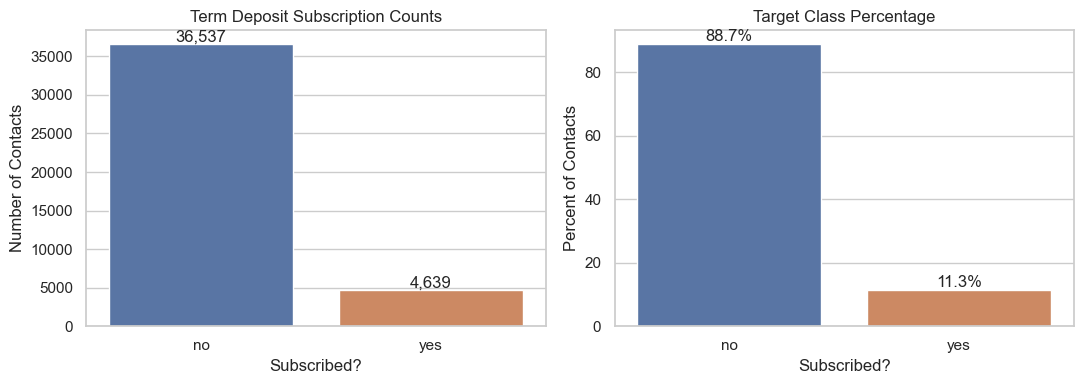

In [143]:
# Target values distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

order = ["no", "yes"]
sns.countplot(data=df, x="y", order=order, palette="deep", ax=axes[0])
axes[0].set_title("Term Deposit Subscription Counts")
axes[0].set_xlabel("Subscribed?")
axes[0].set_ylabel("Number of Contacts")

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="{:,.0f}")

target_share = df["y"].value_counts(normalize=True).reindex(order) * 100
sns.barplot(x=target_share.index, y=target_share.values, ax=axes[1])
axes[1].set_title("Target Class Percentage")
axes[1].set_xlabel("Subscribed?")
axes[1].set_ylabel("Percent of Contacts")

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

From this plot, we can see that only around 11% of clients who were contacted subscribed. Thus, a baseline dummy model that predicts `"no"` for every client would still result in around 89% accuracy.

In [144]:
# Categorical Features vs Target
categorical_cols = df.select_dtypes(exclude=np.number).columns.drop('y').tolist()
print('Categorical columns:', categorical_cols)

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


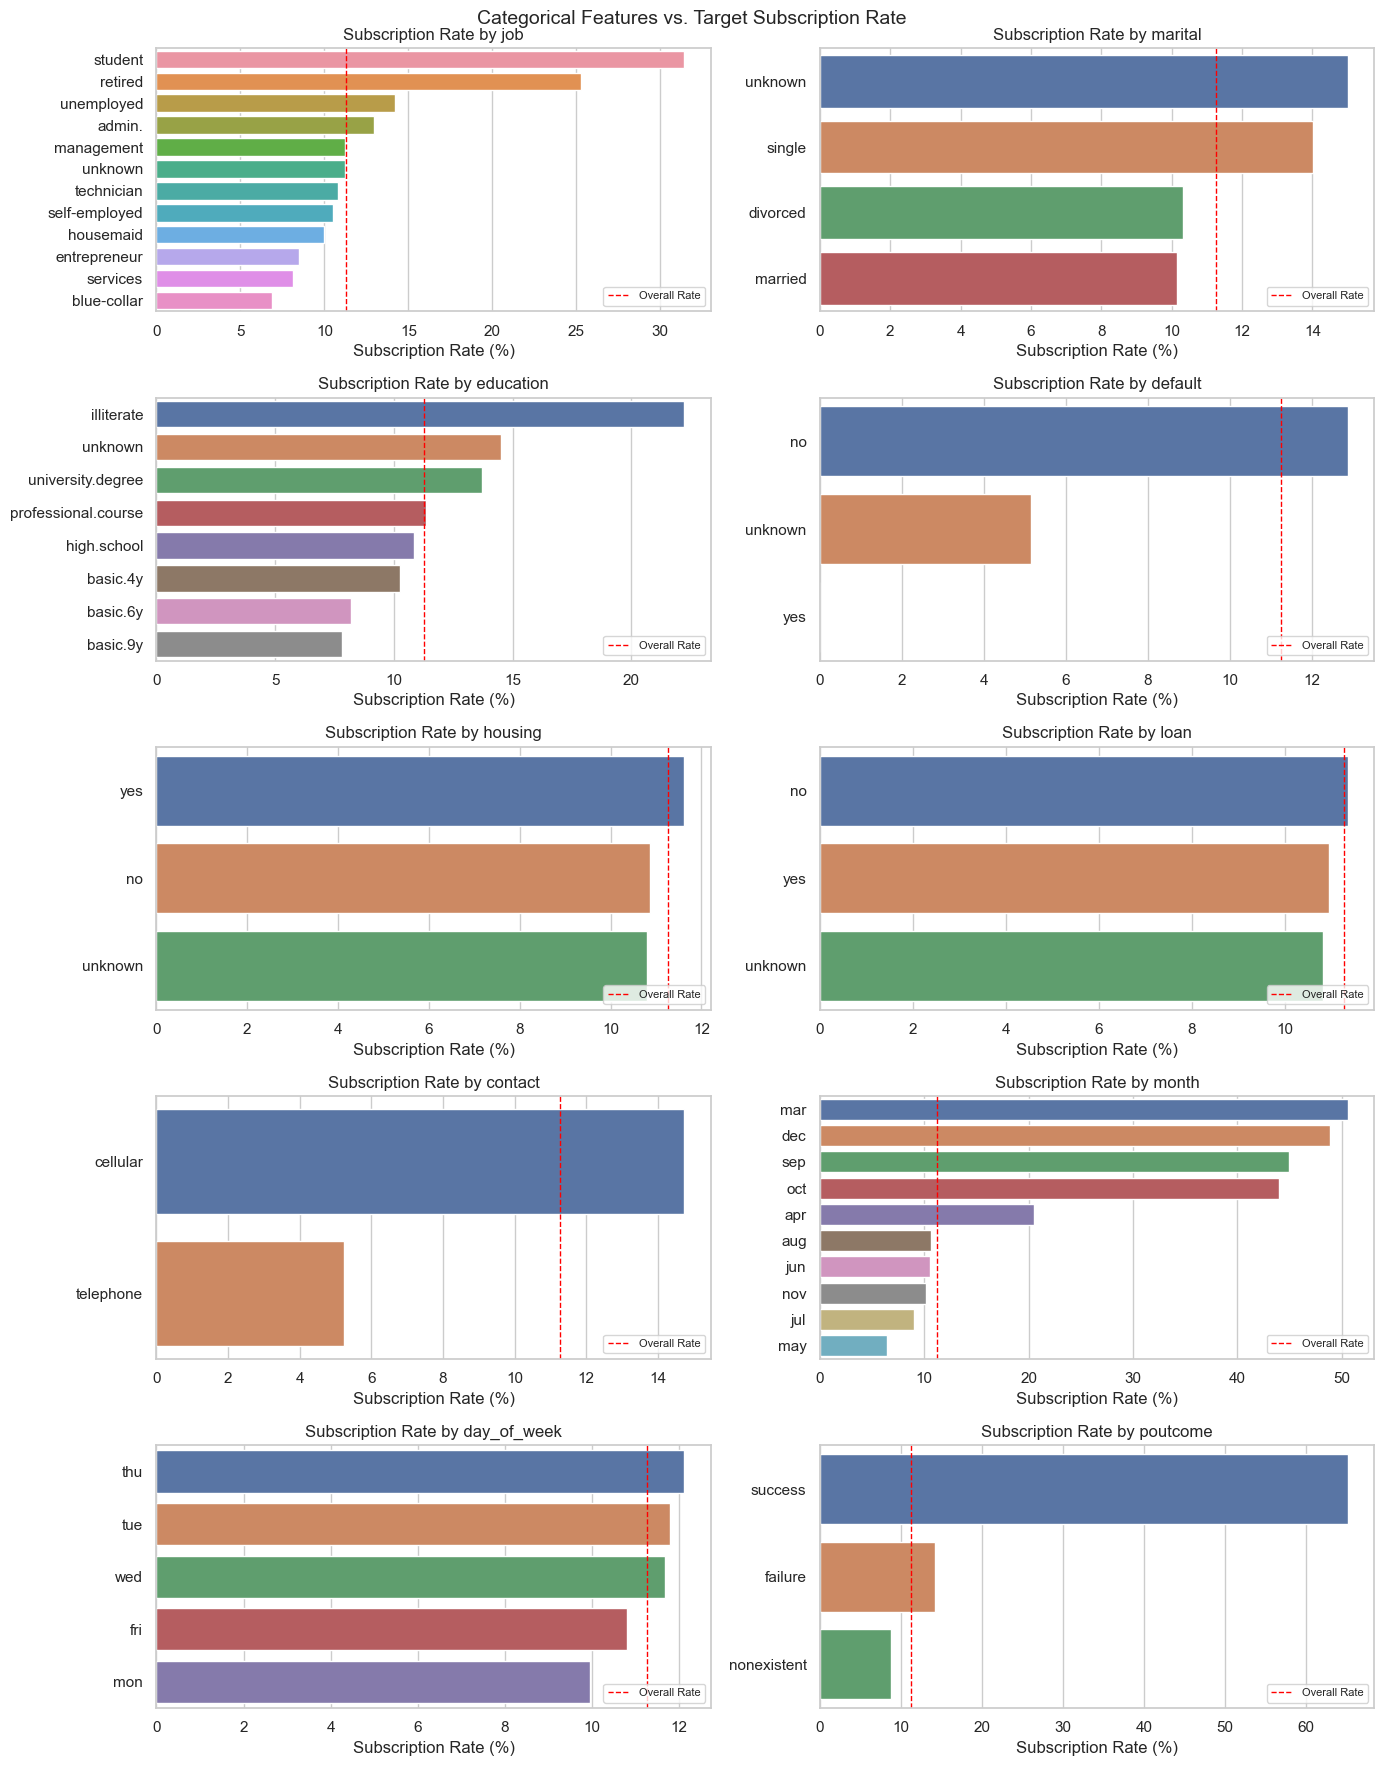

In [145]:
overall_rate = df["target"].mean() * 100

fig, axes = plt.subplots(5, 2, figsize=(14, 18))

for ax, col in zip(axes.ravel(), categorical_cols):
    rates = (df.groupby(col)["target"].mean() * 100).sort_values(ascending=False)
    sns.barplot(x=rates.values, y=rates.index, ax=ax)
    ax.axvline(overall_rate, linestyle="--", color="red", linewidth=1, label = "Overall Rate")
    ax.set_title(f"Subscription Rate by {col}")
    ax.set_xlabel("Subscription Rate (%)")
    ax.set_ylabel("")
    ax.legend(loc='lower right', fontsize=8)
plt.suptitle("Categorical Features vs. Target Subscription Rate", fontsize=14)
plt.tight_layout()
plt.show()


From these graphs we can observe the following: the feature `poutcome = "success"`, meaning that the previous campaign succeeded is the strongest single positive signal, indicating that repeat customers convert at very high rates; the feature `contact = "cellular"` vastly outperforms `contact = "telephone"`; students and retired clients have noticeably higher subscription rates than the overall average; and the month of contact matters substantially, with march, december, september, and october showing the highest conversion rates.

In [146]:
# Distribution of Numeric Features
numeric_cols = df.select_dtypes(include=np.number).columns.drop(["target", "prev_contacted"]).tolist()
print('Numeric columns:', numeric_cols)
df[numeric_cols].describe().round(2)

Numeric columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00
mean,40.02,258.32,2.57,0.22,0.17,0.08,93.58,-40.50,3.62,5167.03
std,10.42,259.31,2.77,1.35,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,0.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,0.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,0.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,27.00,7.00,1.40,94.77,-26.90,5.04,5228.10


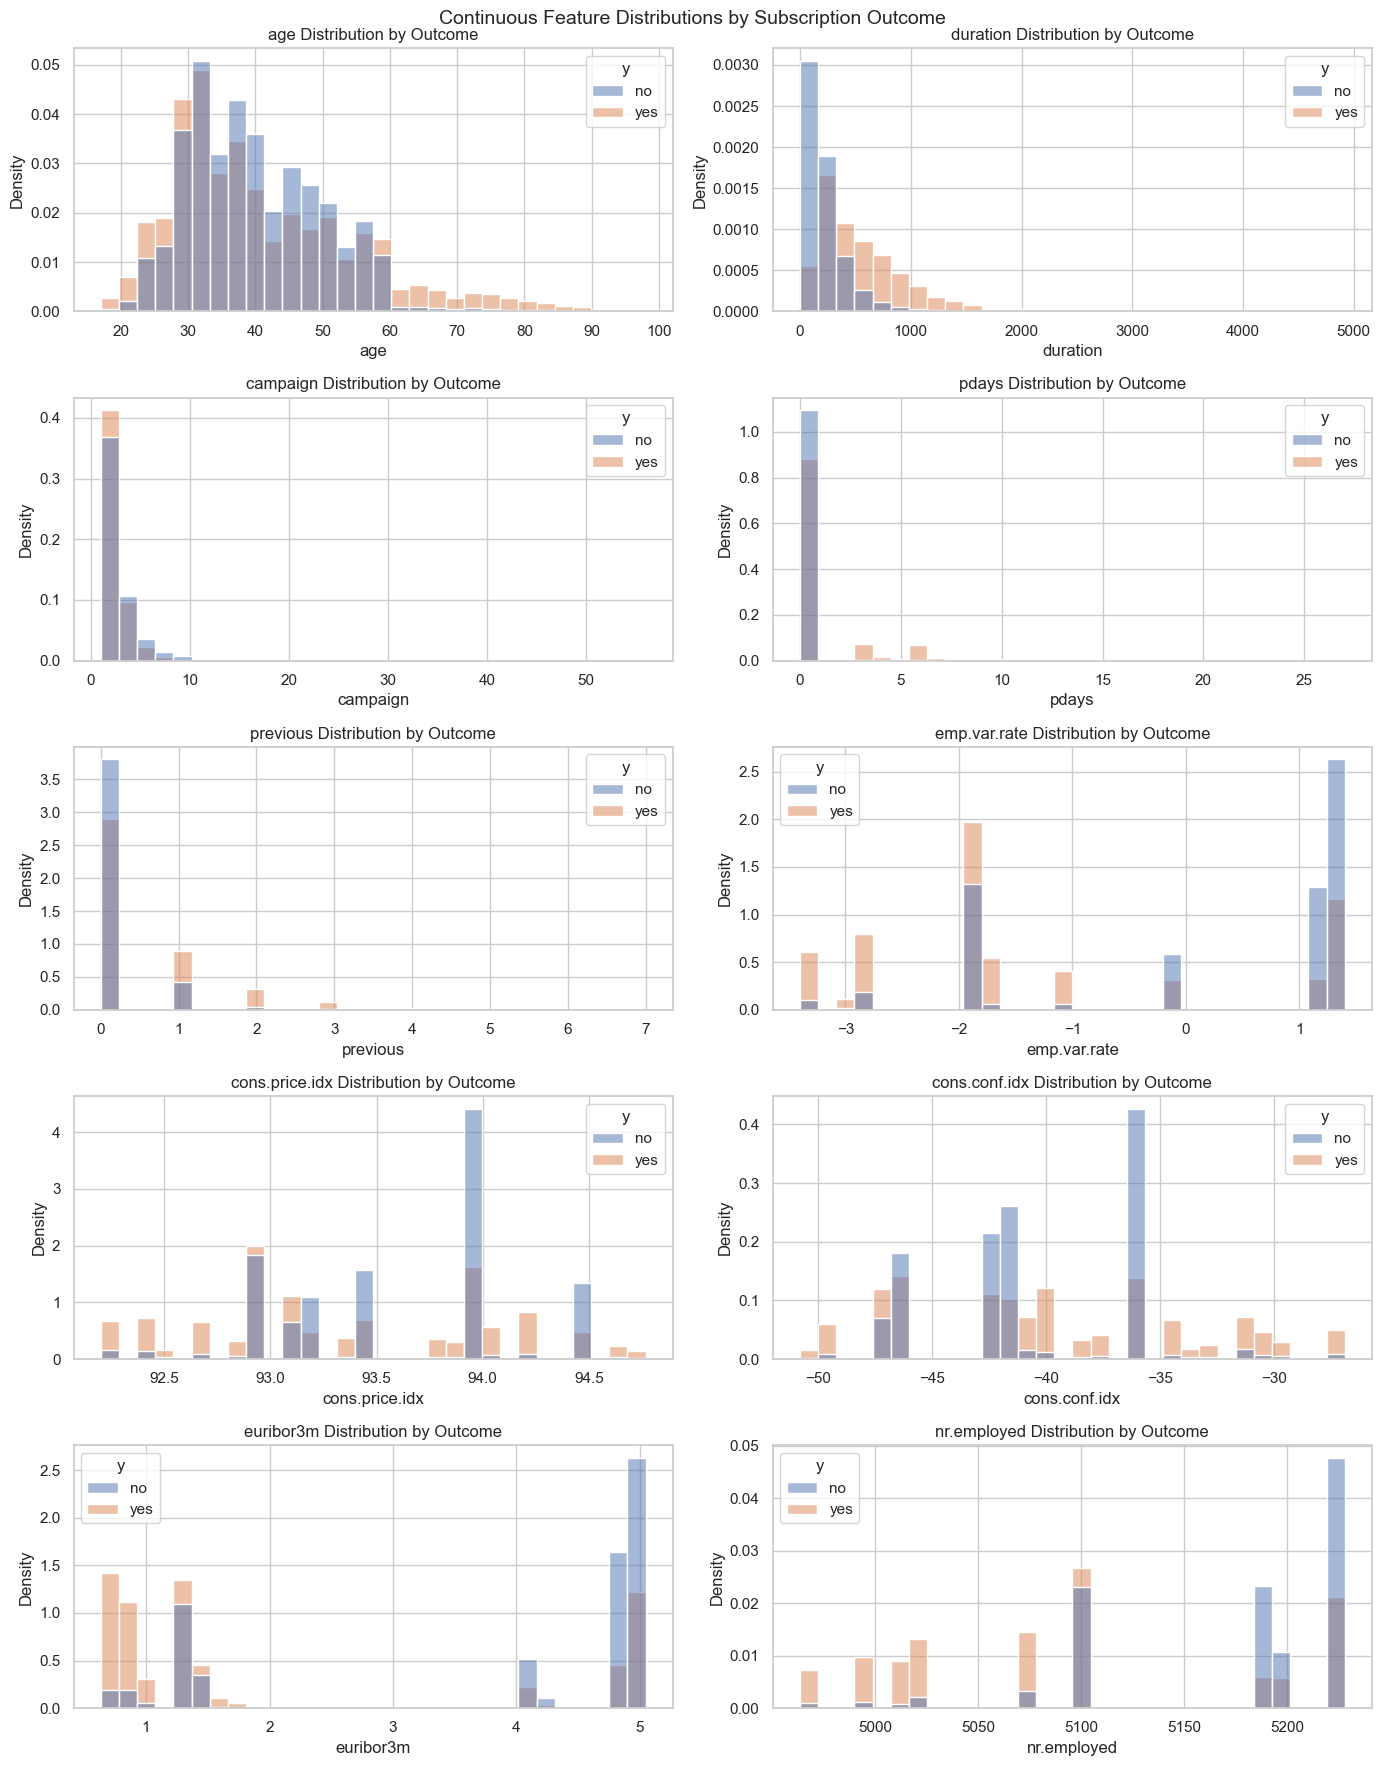

In [147]:
# Histograms of Numeric Features
fig, axes = plt.subplots(5, 2, figsize=(14, 18))

for ax, col in zip(axes.ravel(), numeric_cols):
    sns.histplot(data=df, x=col, hue="y", bins=30, stat="density", common_norm=False, ax=ax)
    ax.set_title(f"{col} Distribution by Outcome")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")

plt.suptitle("Continuous Feature Distributions by Subscription Outcome", fontsize=14)
plt.tight_layout()
plt.show()

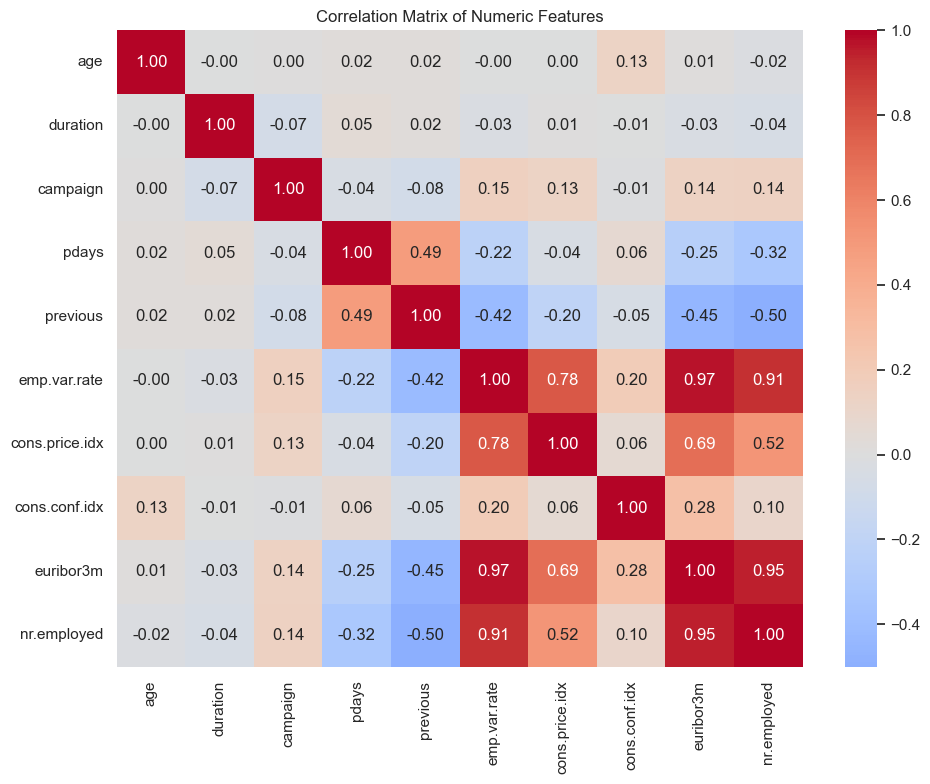

In [148]:
# Correlation Heatmap for Numeric Features
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

From the heatmap, we can see that several macro-economic features (`emp.var.rate`, `euribor3m`, `nr.employed`) are strongly inter-correlated.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [149]:
# As instructed, use only the bank client features (features 1-7 in the feature description)
client_numeric = ["age"]
client_categorical = ["job", "marital", "education", "default", "housing", "loan"]

X_base = df[client_numeric + client_categorical]
y = df["target"]

base_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), client_numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), client_categorical)
])

print(f"Client-only feature matrix: {X_base.shape}")
X_base.head()

Client-only feature matrix: (41176, 7)


,age,job,marital,education,default,housing,loan
0,56,housemaid,married,basic.4y,no,no,no
1,57,services,married,high.school,unknown,no,no
2,37,services,married,high.school,no,yes,no
3,40,admin.,married,basic.6y,no,no,no
4,56,services,married,high.school,no,no,yes


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [150]:
# Stratified train/test split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_base,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training rows: {X_train.shape[0]:,}")
print(f"Testing rows:  {X_test.shape[0]:,}")
print(f"Training positive rate: {y_train.mean() * 100:.2f}%")
print(f"Testing positive rate:  {y_test.mean() * 100:.2f}%")

Training rows: 32,940
Testing rows:  8,236
Training positive rate: 11.27%
Testing positive rate:  11.27%


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

We will establish a baseline model with `DummyClassifier` that always predicts the majority class (`"no"`). Given the imbalanced data, always predicting `"no"` yields an accuracy of 0.8873.

In [151]:
dummy = DummyClassifier(strategy = "most_frequent", random_state = RANDOM_STATE)
dummy.fit(X_train, y_train)

baseline_accuracy = dummy.score(X_test, y_test)
print(f'Baseline accuracy : {baseline_accuracy:.4f}')

Baseline accuracy : 0.8873


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [152]:
logreg_simple = Pipeline([
    ("prep", base_preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

logreg_simple.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age']),
                                                 ('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

### Problem 9: Score the Model

What is the accuracy of your model?

In [153]:
simple_train_acc = logreg_simple.score(X_train, y_train)
simple_test_acc = logreg_simple.score(X_test, y_test)

print(f"Logistic Regression training accuracy: {simple_train_acc:.4f}")
print(f"Logistic Regression testing accuracy: {simple_test_acc:.4f}")
print(f"Baseline accuracy: {baseline_accuracy:.4f}")

Logistic Regression training accuracy: 0.8873
Logistic Regression testing accuracy: 0.8873
Baseline accuracy: 0.8873


Using only the bank client features, we see that Logistic Regression performs the same as the baseline, meaning that these features are not enough to strongly predict term-deposit subscription.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

Using the simple settings, we will compare the performance of Logistic Regression, K-Nearest Neighbors, Decision Tree, and SVM models. We will compare the models performance in regards to training time, training accuracy, and test accuracy.

In [ ]:
default_models = {
    "Logistic Regression": LogisticRegression(max_iter = 1000, random_state = RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state = RANDOM_STATE),
    "SVM": SVC(random_state = RANDOM_STATE)
}

results = []

for name, model in default_models.items():
    pipeline = Pipeline([
        ('preprocessor', base_preprocessor),
        (name, model)
    ])

    # Fit the model and time it
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    fit_time = time.time() - start_time

    # Evaluate on training and test sets
    train_score = pipeline.score(X_train, y_train)
    test_score = pipeline.score(X_test, y_test)

    # Append the results
    results.append({
        "Model": name, 
        "Train Time (s)": fit_time,
        "Train Accuracy": train_score, 
        "Test Accuracy": test_score
    })

default_results = pd.DataFrame(results).set_index("Model")
default_results

,Train Time (s),Train Accuracy,Test_Accuracy
Model,,,
Logistic Regression,0.550986,0.887341,0.887324
KNN,0.109435,0.889557,0.876032
Decision Tree,3.315791,0.917608,0.863526
SVM,164.267038,0.888100,0.887810


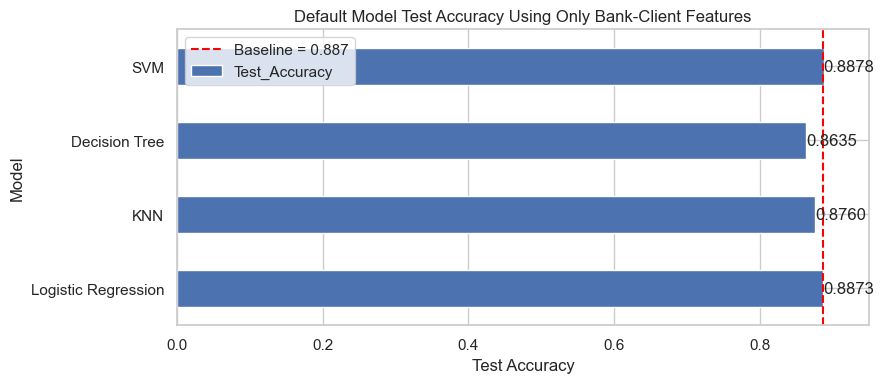

In [155]:
plt.figure(figsize=(9, 4))
ax = default_results["Test_Accuracy"].plot(kind = "barh")
plt.axvline(baseline_accuracy, linestyle="--", color="red", label=f"Baseline = {baseline_accuracy:.3f}")
plt.title("Default Model Test Accuracy Using Only Bank-Client Features")
plt.xlabel("Test Accuracy")
plt.ylabel("Model")
for c in ax.containers:
    ax.bar_label(c, fmt="%.4f")
ax.set_xlim(0, 0.95)
plt.legend()
plt.tight_layout()
plt.show()

From these results, we can see that all four models perform similarly to the baseline model. Ultimately, Decision Tree performs best in training accuracy but worst in test accuracy, while SVC performs best in test accuracy but is the slowest model by far. All models performed better than the baseline in training, however Decision Tree performed worse than the baseline in test accuracy while the other three performed slightly better than baseline.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

To improve our models, we will (1) include the full feature set (except for `duration` since it leaks the target), (2) utilize hyperparameter tuning via `GridSearchCV`, and (3) adjust our performance metric by evaluating our models using ROC-AUC instead of accuracy, since we saw that accuracy is misleading given the imbalanced dataset. Our goal is to rank clients by likelihood of subscription, so ROC-AUC makes sense as an evaluation metric since it evaluates how well the model separates likely subscribers from non-subscribers across possible thresholds.

In [156]:
# Full feature set
drop_cols = ["y", "target", "duration"]
feature_cols = [col for col in df.columns if col not in drop_cols]

X = df[feature_cols]

numeric = X.select_dtypes(include="number").columns.tolist()
categorical = X.select_dtypes(include="object").columns.tolist()

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical)
])

print(f"Full feature set: {len(numeric)} numeric features & {len(categorical)} categorical features")
print("Excluded duration feature due to target leakage")

Full feature set: 10 numeric features & 10 categorical features
Excluded duration feature due to target leakage


To keep the notebook from becoming too slow due to SVM execution, the grid search will be performed on a stratified sample of the training data. After choosing the best hyperparameters, each best model is refit on the full training set and evaluated on the same test set.

In [157]:
X_tune, _, y_tune, _ = train_test_split(
    Xf_train,
    yf_train,
    train_size=3000,
    random_state=RANDOM_STATE,
    stratify=yf_train
)

param_grid = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
        {"model__C": [0.01, 0.1, 1, 10]}
    ),
    "KNN": (
        KNeighborsClassifier(),
        {"model__n_neighbors": [11, 21, 41], "model__weights": ["uniform", "distance"]}
    ),
    "Decision Tree": (
        DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
        {"model__max_depth": [3, 5, 7, 10], "model__min_samples_leaf": [20, 50, 100]}
    ),
    "SVM": (
        SVC(class_weight="balanced", random_state=RANDOM_STATE),
        {"model__C": [0.1, 1, 10]}
    )
}

tuned_models = {}
search_results = []

for name, (estimator, grid) in param_grid.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])

    search = GridSearchCV(
        pipe,
        param_grid=grid,
        scoring="roc_auc",
        cv=5,
        n_jobs=1
    )

    start = time.time()
    search.fit(X_tune, y_tune)
    tune_time = time.time() - start

    best_model = search.best_estimator_
    best_model.fit(Xf_train, yf_train)
    tuned_models[name] = best_model

    search_results.append({
        "Model": name,
        "Best Parameters": search.best_params_,
        "CV ROC-AUC": round(search.best_score_, 4),
        "Tune Time (seconds)": round(tune_time, 2)
    })

full_results = pd.DataFrame(search_results).set_index("Model")

full_results["Best Parameters"] = full_results["Best Parameters"].apply(
    lambda x: ", ".join([f"{key}: {value}" for key, value in x.items()])
)

full_results

,Best Parameters,CV ROC-AUC,Tune Time (seconds)
Model,,,
Logistic Regression,model__C: 0.1,0.7722,1.88
KNN,"model__n_neighbors: 41, model__weights: distance",0.7364,2.20
Decision Tree,"model__max_depth: 5, model__min_samples_leaf: 100",0.7595,3.00
SVM,model__C: 0.1,0.7499,13.29


In [158]:
def model_scores(model, X):
    """Return a continuous score for ROC-AUC."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)

eval_rows = []

for name, model in tuned_models.items():
    y_pred = model.predict(Xf_test)
    y_score = model_scores(model, Xf_test)

    eval_rows.append({
        "Model": name,
        "Test ROC-AUC": round(roc_auc_score(yf_test, y_score), 4),
        "Test Accuracy": round(accuracy_score(yf_test, y_pred), 4),
        "Test Precision (yes)": round(precision_score(yf_test, y_pred), 4),
        "Test Recall (yes)": round(recall_score(yf_test, y_pred), 4),
        "Test F1 (yes)": round(f1_score(yf_test, y_pred), 4)
    })

final_results = pd.DataFrame(eval_rows).set_index("Model")
final_results

,Test ROC-AUC,Test Accuracy,Test Precision (yes),Test Recall (yes),Test F1 (yes)
Model,,,,,
Logistic Regression,0.8000,0.8295,0.3578,0.6455,0.4604
KNN,0.7623,0.8959,0.5937,0.2425,0.3443
Decision Tree,0.7966,0.8464,0.3877,0.6272,0.4792
SVM,0.7831,0.8448,0.3858,0.6369,0.4805


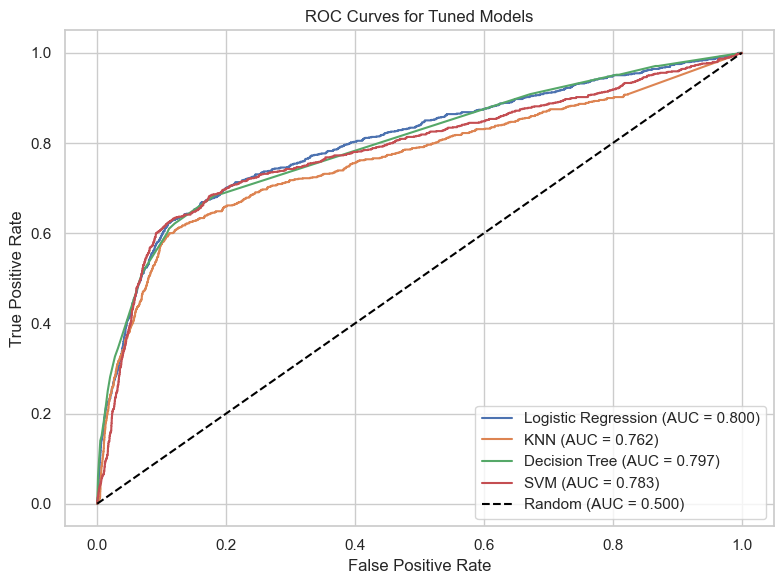

In [159]:
# ROC Curves
plt.figure(figsize=(8, 6))

for name, model in tuned_models.items():
    y_score = model_scores(model, Xf_test)
    fpr, tpr, _ = roc_curve(yf_test, y_score)
    auc = roc_auc_score(yf_test, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="Random (AUC = 0.500)")
plt.title("ROC Curves for Tuned Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

We can see from these final results that the tuned models using the full feature set perform much better than the bank client only models when evaluated by ROC-AUC. 

When evaluated using test ROC-AUC, we see that Logistic Regression performed the best, followed by Decision Tree, SVM, and finally KNN.

The strongest models are close in performance, so interpretability and business usability matter in the final choice of the model. Logistic Regression models are especially useful in this case due to their coefficients being easier to explain to nontechnical stakeholders.

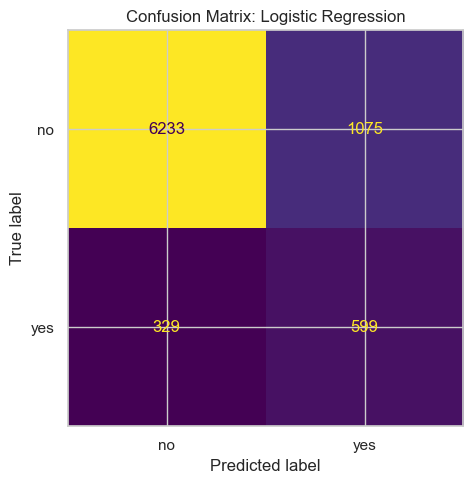

Classification Report: Logistic Regression
              precision    recall  f1-score   support

          no       0.95      0.85      0.90      7308
         yes       0.36      0.65      0.46       928

    accuracy                           0.83      8236
   macro avg       0.65      0.75      0.68      8236
weighted avg       0.88      0.83      0.85      8236



In [160]:
# Confusion Matrix for Best Model
best_model = tuned_models["Logistic Regression"]
best_pred = best_model.predict(Xf_test)

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(
    confusion_matrix(yf_test, best_pred),
    display_labels=["no", "yes"]
).plot(ax=ax, colorbar=False)

plt.title(f"Confusion Matrix: Logistic Regression")
plt.tight_layout()
plt.show()

print(f"Classification Report: Logistic Regression")
print(classification_report(yf_test, best_pred, target_names=["no", "yes"]))

Because Logistic Regression is interpretable and was our best performing model, it is useful for understanding which features are associated with a higher or lower likelihood of subscription.

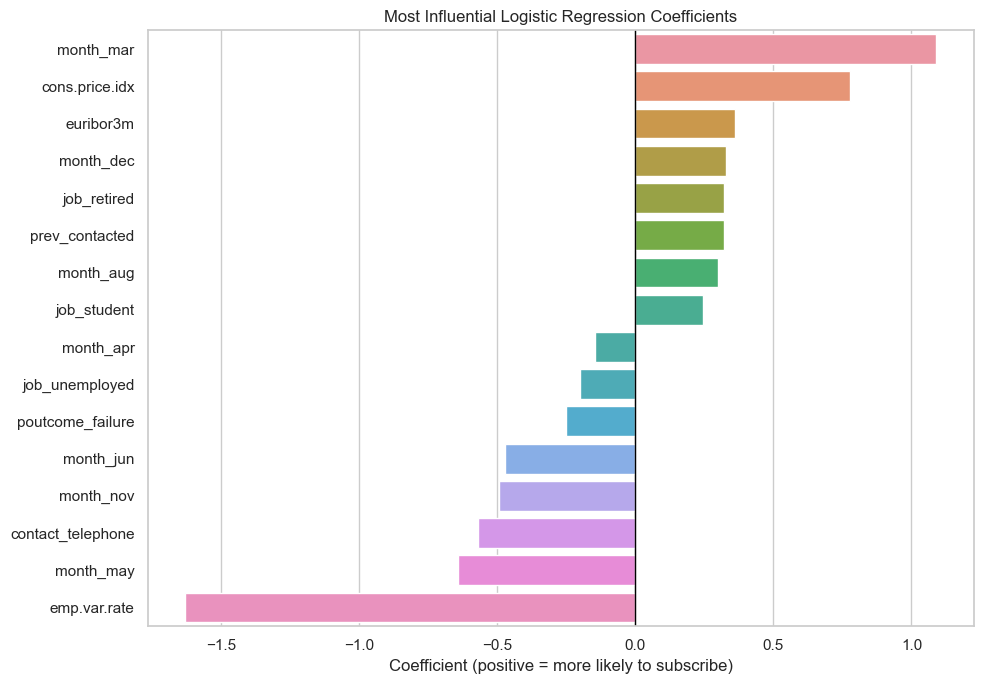

In [161]:
logreg_model = tuned_models["Logistic Regression"]

cat_encoder = logreg_model.named_steps["preprocessor"].named_transformers_["cat"]
feature_names = numeric + list(cat_encoder.get_feature_names_out(categorical))

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": logreg_model.named_steps["model"].coef_[0]
})

coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])
coef_df = coef_df.sort_values("coefficient")

top_coefficients = pd.concat([coef_df.head(8), coef_df.tail(8)])

top_coefficients = top_coefficients.sort_values("coefficient", ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=top_coefficients, x="coefficient", y="feature")
plt.axvline(0, color="black", linewidth=1)
plt.title("Most Influential Logistic Regression Coefficients")
plt.xlabel("Coefficient (positive = more likely to subscribe)")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [166]:
coef_df_display = coef_df.set_index("feature")
coef_df_display.tail(10).sort_values("coefficient", ascending=False).round(3)

,coefficient,odds_ratio
feature,,
month_mar,1.090,2.975
cons.price.idx,0.777,2.174
euribor3m,0.361,1.435
month_dec,0.327,1.386
job_retired,0.321,1.379
prev_contacted,0.321,1.378
month_aug,0.301,1.351
job_student,0.243,1.276
education_illiterate,0.193,1.213


Positive coefficients are associated with higher odds of subscribing. We can see from the figure that the strongest signals generally include previous campaign success, contact timing/channel, and economic conditions. Because the economic variables are strongly correlated, their individual coefficients should be interpreted carefully, but together these features show that the broader economic environment matters.

### Problem 12: Findings, Actionable Insights, Next Steps and Recommendations

From this assignment, we have found the following:

1. Subscriptions are rare. Only about 11% of clients subscribe, so the bank should not evaluate models by accuracy alone.
2. Client demographics alone are not enough. Models using only bank-client features perform close to the baseline.
3. Campaign and economic context improve prediction. Adding contact information, previous campaign outcomes, and economic indicators increases ROC-AUC substantially.
4. Past campaign success is one of the strongest signals. Clients who subscribed in a previous campaign are much more likely to subscribe again.
5. Channel and timing matter. Cellular contacts and certain months show higher subscription rates.
6. Logistic Regression is a strong practical choice. The best model may vary slightly by sample, but Logistic Regression is a strong practical option because it balances performance and interpretability.

We can thus recommend the following actionable insights:

- Prioritize clients with previous campaign success because they are the most responsive group.
- Use model scores to rank the call list instead of calling clients in an untargeted order.
- Favor cellular outreach when available because it has higher observed conversion.
- Track ROC-AUC, recall, precision, and F1 instead of relying only on accuracy.
- Use Logistic Regression as a starting deployment model because it balances performance and interpretability.

To further improve model performance, here are some recommended next steps:

1. Tune the decision threshold. The default threshold may not be best for the business. The bank should choose a threshold based on call cost and expected value of a subscription.
2. Run a lift/gains analysis. Marketing managers would benefit from knowing how many subscribers can be captured by calling the top 10%, 20%, or 30% of ranked clients.
3. Validate over time. Since economic conditions change, train on earlier campaigns and test on later campaigns before deployment.
4. Consider additional models. Random Forest or Gradient Boosting may improve performance, but the current assignment focuses on KNN, Logistic Regression, Decision Trees, and SVM.
5. Collect more pre-call client features. More client-level data could improve targeting without relying on information only known after contact.